# KNN IMPLEMENTATION

<br>

**Name:** Sumit Mund
**SIC:** 24BCSH05
**Roll No.:** 15
<br>
**Topic:** K-Nearest Neighbors (KNN) Implementation


### KNN FROM SCARTCH

In [23]:
from collections import Counter
import math
import numpy as np
import pandas as pd

df = pd.read_csv("dataknn1.csv")
print("\n Dataframe Info")
df.info()

train_data = df.iloc[:, 1:-1].values 
y = df.iloc[:, -1].values
test_points = [0, 0, 0]

print("\n Split Data Shapes ")
print(f"Train data shape: {train_data.shape}")
print(f"Labels shape: {y.shape}")
print(f"Test point: {test_points}")



 Dataframe Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   obs     6 non-null      int64 
 1   x1      6 non-null      int64 
 2   x2      6 non-null      int64 
 3   x3      6 non-null      int64 
 4   y       6 non-null      object
dtypes: int64(4), object(1)
memory usage: 368.0+ bytes

 Split Data Shapes 
Train data shape: (6, 3)
Labels shape: (6,)
Test point: [0, 0, 0]


##### Distance Matrix Calculation (Euclidean Distance)

$$
d = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$


In [7]:
def euclidean_distance(a, b):
    return math.sqrt(sum((a1 - b1) ** 2 for a1, b1 in zip(a, b))) #zip - combine two iterable element  by element

In [8]:
def knnClassifier(train_data, train_labels, test_point, k):
    dist_list = []

    # Calculate dist from test points
    for i in range(len(train_data)):
        distance = euclidean_distance(test_point, train_data[i])
        dist_list.append((distance, train_labels[i]))
        print(f"Distance {i+1}: {distance}")

    # Sort distances 
    dist_list.sort(key=lambda x: x[0])
    print("\nSorted Distance List:")
    print(dist_list)

    # Select k 
    k_near = [label for (_, label) in dist_list[:k]]
    print(f"\n{k} Nearest Neighbors:")
    print(k_near)

    # Find majority class
    most_common = Counter(k_near).most_common(1)
    print("\nClass Frequency:")
    print(most_common)

    return most_common[0][0]

In [9]:
# test it
k = 3
predicted_class = knnClassifier(train_data, y, test_points, k)
print(f"\nPredicted Class: {predicted_class}")

Distance 1: 3.0
Distance 2: 2.0
Distance 3: 3.1622776601683795
Distance 4: 2.23606797749979
Distance 5: 1.4142135623730951
Distance 6: 1.7320508075688772

Sorted Distance List:
[(1.4142135623730951, 'green'), (1.7320508075688772, 'red'), (2.0, 'red'), (2.23606797749979, 'green'), (3.0, 'red'), (3.1622776601683795, 'red')]

3 Nearest Neighbors:
['green', 'red', 'red']

Class Frequency:
[('red', 2)]

Predicted Class: red


### KNN WITH SK-LEARN WITH IRIS DATA SET

In [9]:
#import lib
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris #loading rish dataset from sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [10]:
## Irish - dataset
iris = load_iris() #in array form
df = pd.DataFrame(iris.data, columns=iris.feature_names) #convert to dataframe
df['target'] = iris.target
print(df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0         0  

In [ ]:
df.head()

In [56]:
df.info() #info about datset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   obs     6 non-null      int64 
 1   x1      6 non-null      int64 
 2   x2      6 non-null      int64 
 3   x3      6 non-null      int64 
 4   y       6 non-null      object
dtypes: int64(4), object(1)
memory usage: 368.0+ bytes


### Iris Dataset

- **Samples:** 150
- **Features:** 4
- **Classes:** 3
- **Classes:** Setosa, Versicolor, Virginica
- **Features:** Sepal Length, Sepal Width, Petal Length, Petal Width

In [11]:
# Separate features and labels
X = iris.data
y = iris.target

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(f"Traning data shape {X_train.shape} , testing_data shape {X_test.shape}")

Traning data shape (120, 4) , testing_data shape (30, 4)


In [12]:
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [13]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

# Train the model
knn.fit(X_train, y_train)

# Predict test data
y_pred = knn.predict(X_test)

In [14]:
# Display predictions
print("\nActual Labels:")
print(y_test)

print("\nPredicted Labels:")
print(y_pred)


Actual Labels:
[2 1 0 2 2 1 2 2 2 0 1 2 0 2 0 2 0 0 1 2 1 1 2 0 1 1 2 2 0 0]

Predicted Labels:
[2 1 0 2 1 1 2 2 2 0 1 2 0 2 0 2 0 0 2 2 1 1 2 0 1 1 2 2 0 0]


In [18]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[ 9  0  0]
 [ 0  7  1]
 [ 0  1 12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.88      0.88      0.88         8
           2       0.92      0.92      0.92        13

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [21]:
# plotting the graph in range
error = []

for i in range(1,100):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    y_pred_i = knn.predict(X_test)
    error.append(np.mean(y_pred_i!=y_test ))
    
print(error)

[0.06666666666666667, 0.06666666666666667, 0.03333333333333333, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.03333333333333333, 0.03333333333333333, 0.03333333333333333, 0.03333333333333333, 0.03333333333333333, 0.03333333333333333, 0.06666666666666667, 0.06666666666666667, 0.03333333333333333, 0.03333333333333333, 0.03333333333333333, 0.06666666666666667, 0.03333333333333333, 0.06666666666666667, 0.03333333333333333, 0.06666666666666667, 0.03333333333333333, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.16666666666666666, 0.13333333333333333, 0.16666666666666666, 0.13333333333333333, 0.3, 0.3, 0.43333333

Text(0, 0.5, 'Error(mean)')

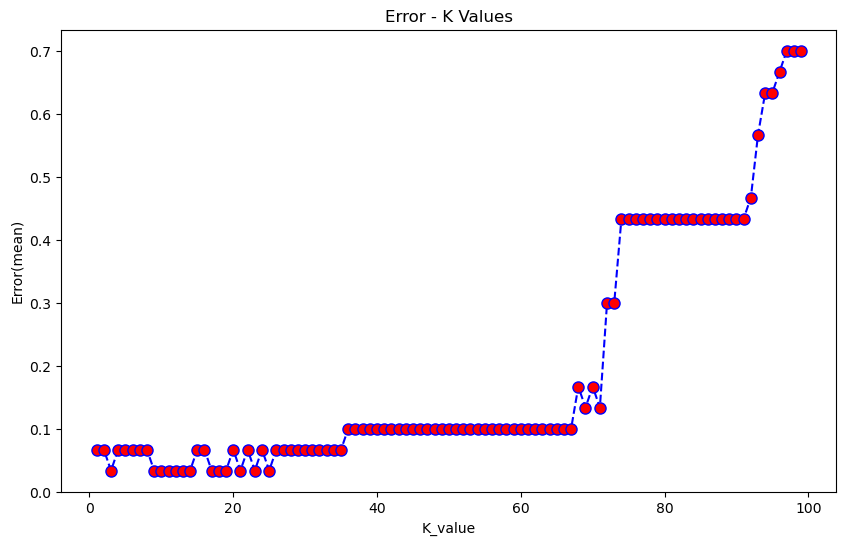

In [28]:
#plotting the error
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(range(1,100),error,color='blue',linestyle='dashed',marker='o',markerfacecolor = 'red',markersize = 8)
plt.title("Error - K Values")
plt.xlabel("K_value")
plt.ylabel("Error(mean)")

### KNN REGRESSION FROM SCRATCH

In [32]:
#import the dataset
df1 = pd.read_csv('knndata2.csv')
print(df1)

   Sl No  Height  Weight  Target
0      1     150      50     1.5
1      2     155      55     1.2
2      3     160      60     1.8
3      4     161      59     2.1
4      5     158      64     1.7


In [33]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sl No   5 non-null      int64  
 1   Height  5 non-null      int64  
 2   Weight  5 non-null      int64  
 3   Target  5 non-null      float64
dtypes: float64(1), int64(3)
memory usage: 288.0 bytes


In [40]:
train_data = df1.iloc[:, 1:-1].values 
y = df1.iloc[:, -1].values
test_points = [157,54]
print(train_data)
print(y)

print(f"Train data shape: {train_data.shape}")
print(f"Labels shape: {y.shape}")
print(f"Test points {test_points}")

[[150  50]
 [155  55]
 [160  60]
 [161  59]
 [158  64]]
[1.5 1.2 1.8 2.1 1.7]
Train data shape: (5, 2)
Labels shape: (5,)
Test points [157, 54]


In [44]:
def euclidean_distance(a, b):
    return math.sqrt(sum((a1 - b1) ** 2 for a1, b1 in zip(a, b))) #zip - combine two iterable element  by element

In [47]:
def knnRegression(train_data, train_labels, test_point, k):
    dist_list = []

    # Calculate dist from test points
    for i in range(len(train_data)):
        distance = euclidean_distance(test_point, train_data[i])
        dist_list.append((distance, train_labels[i]))
        print(f"Distance {i+1}: {distance}")

    # Sort distances 
    dist_list.sort(key=lambda x: x[0])
    print("\nSorted Distance List:")
    print(dist_list)

    # Select k 
    k_near = [label for (_,label) in dist_list[:k]]
    print(f"\n{k} Nearest Neighbors:")
    print(k_near)



    return np.mean(k_near)

In [48]:
# test it
k = 3
predicted_class = knnRegression(train_data, y, test_points, k)
print(f"\nPredicted Class: {predicted_class}")

Distance 1: 8.06225774829855
Distance 2: 2.23606797749979
Distance 3: 6.708203932499369
Distance 4: 6.4031242374328485
Distance 5: 10.04987562112089

Sorted Distance List:
[(2.23606797749979, 1.2), (6.4031242374328485, 2.1), (6.708203932499369, 1.8), (8.06225774829855, 1.5), (10.04987562112089, 1.7)]

3 Nearest Neighbors:
[1.2, 2.1, 1.8]

Predicted Class: 1.7


### KNN REGRESSION WITH SKLEARN

In [66]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(train_data, y, test_size=0.2)

print(f"Traning data shape {X_train.shape} , testing_data shape {X_test.shape}")

Traning data shape (4, 2) , testing_data shape (1, 2)


In [68]:
from sklearn.neighbors import KNeighborsRegressor
k = 3
knn = KNeighborsRegressor(n_neighbors=k,)
test_points = [[157, 54]]
# Train the model
knn.fit(train_data, y)

# Predict test data
y_pred = knn.predict(test_points)
print(y_pred)

[1.7]
